# Experiment 1: FIND-S Algorithm

DATASET SAVED AS FindS_Dataset.csv


DATASET
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes


FIRST FIVE RECORDS
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes


FEATURES
[['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']
 ['Sunny' 'Warm' 'High' 'Strong' 'Warm' 'Same']
 ['Rainy' 'Cold' 'High' 'Strong' 'Warm' 'Change']
 ['Sunny' 'Warm' 'High' 'Strong' 'Cool' 'Change']]


TARGET
['Yes' 'Yes' 'No' 'Yes']


FIND-S ALGORITHM EXECUTION

Positive Example 1
Initialize Hypothesis:
['Sunny' 'Warm' 'N

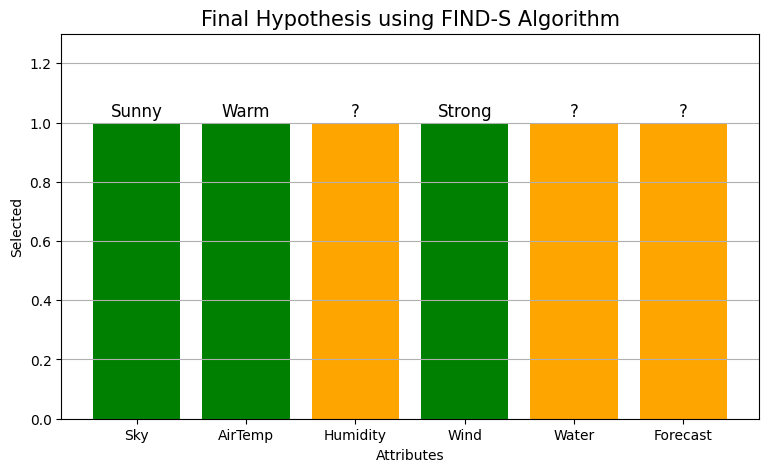



RESULT
['Sunny' 'Warm' '?' 'Strong' '?' '?']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

df.to_csv("FindS_Dataset.csv", index=False)

print("="*60)
print("DATASET SAVED AS FindS_Dataset.csv")
print("="*60)


dataset = pd.read_csv("FindS_Dataset.csv")

print("\n")
print("="*60)
print("DATASET")
print("="*60)

print(dataset)

print("\n")
print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

print(dataset.head())
concepts = dataset.iloc[:, :-1].values
target = dataset.iloc[:, -1].values

print("\n")
print("="*60)
print("FEATURES")
print("="*60)

print(concepts)

print("\n")
print("="*60)
print("TARGET")
print("="*60)

print(target)


hypothesis = None

print("\n")
print("="*60)
print("FIND-S ALGORITHM EXECUTION")
print("="*60)

for i in range(len(concepts)):

    if target[i] == "Yes":

        if hypothesis is None:

            hypothesis = concepts[i].copy()

            print(f"\nPositive Example {i+1}")
            print("Initialize Hypothesis:")
            print(hypothesis)

        else:

            for j in range(len(hypothesis)):

                if hypothesis[j] != concepts[i][j]:

                    hypothesis[j] = '?'

            print(f"\nPositive Example {i+1}")
            print("Updated Hypothesis:")
            print(hypothesis)

    else:

        print(f"\nNegative Example {i+1} Ignored")



print("\n")
print("="*60)
print("FINAL MOST SPECIFIC HYPOTHESIS")
print("="*60)

print(hypothesis)

result = pd.DataFrame({

    "Attribute": dataset.columns[:-1],

    "Final Hypothesis": hypothesis

})

print("\n")
print("="*60)
print("RESULT TABLE")
print("="*60)

print(result)


colors = []

for value in hypothesis:

    if value == '?':

        colors.append("orange")

    else:

        colors.append("green")

plt.figure(figsize=(9,5))

bars = plt.bar(result["Attribute"],
               [1]*len(result),
               color=colors)

plt.title("Final Hypothesis using FIND-S Algorithm",
          fontsize=15)

plt.xlabel("Attributes")

plt.ylabel("Selected")

for bar, value in zip(bars, hypothesis):

    plt.text(bar.get_x()+bar.get_width()/2,
             1.02,
             value,
             ha='center',
             fontsize=12)

plt.ylim(0,1.3)

plt.grid(axis='y')

plt.show()

print("\n")
print("="*60)
print("RESULT")
print("="*60)


print(hypothesis)

# Experiment 2: Candidate-Elimination Algorithm

Dataset:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Specific Hypothesis (S):
['Sunny' 'Warm' '?' 'Strong' '?' '?']

General Hypothesis (G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']

Result Table:
  Attribute Specific Hypothesis
0       Sky               Sunny
1   AirTemp                Warm
2  Humidity                   ?
3      Wind              Strong
4     Water                   ?
5  Forecast                   ?


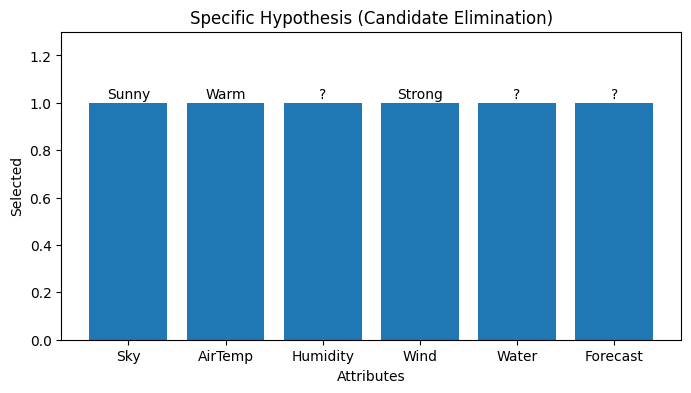

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Sample Dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Separate Features and Target
concepts = df.iloc[:, :-1].values
target = df.iloc[:, -1].values

# Initialize Specific and General Hypotheses
S = concepts[0].copy()
G = [['?' for _ in range(len(S))] for _ in range(len(S))]

# Candidate Elimination Algorithm
for i, instance in enumerate(concepts):

    if target[i] == "Yes":

        for j in range(len(S)):
            if S[j] != instance[j]:
                S[j] = '?'
                G[j][j] = '?'

    else:

        for j in range(len(S)):
            if instance[j] != S[j]:
                G[j][j] = S[j]
            else:
                G[j][j] = '?'

# Remove duplicate rows
G = [g for g in G if g != ['?'] * len(S)]

print("\nSpecific Hypothesis (S):")
print(S)

print("\nGeneral Hypothesis (G):")
for g in G:
    print(g)

# Result Table
result = pd.DataFrame({
    "Attribute": df.columns[:-1],
    "Specific Hypothesis": S
})

print("\nResult Table:")
print(result)

# Visualization
plt.figure(figsize=(8,4))
plt.bar(result["Attribute"], [1]*len(result))
plt.title("Specific Hypothesis (Candidate Elimination)")
plt.xlabel("Attributes")
plt.ylabel("Selected")

for i, value in enumerate(S):
    plt.text(i, 1.02, value, ha='center')

plt.ylim(0, 1.3)
plt.show()

# Experiment 3: Decision Tree based ID3 Algorithm

Dataset:

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Prediction Table:

     Outlook Temperature Humidity    Wind Play Prediction
0      Sunny         Hot     High    Weak   No         No
1      Sunny         Hot     High  Strong   No         No
2   Overcast         Hot     High    Weak  Yes        Yes
3       Rain        Mild     High

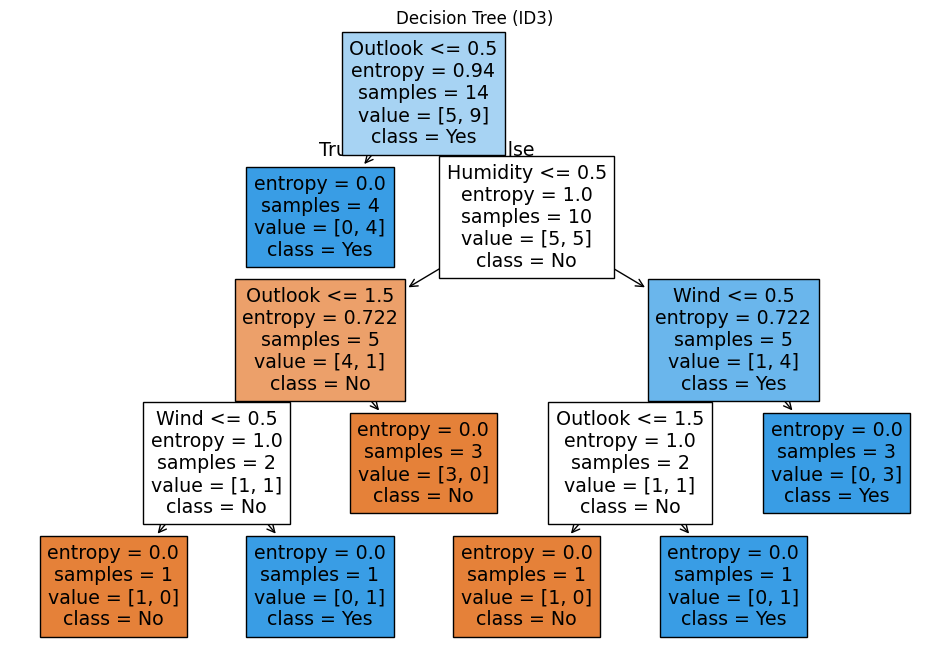

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -----------------------------
# Dataset
# -----------------------------
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                'Overcast','Sunny','Sunny','Rain',
                'Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool',
                    'Cool','Mild','Cool','Mild',
                    'Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal',
                 'Normal','High','Normal','Normal',
                 'Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong',
             'Strong','Weak','Weak','Weak',
             'Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No',
             'Yes','No','Yes','Yes',
             'Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# -----------------------------
# Encode Categorical Data
# -----------------------------
le = LabelEncoder()

df_encoded = df.copy()

for col in df.columns:
    df_encoded[col] = le.fit_transform(df[col])

X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

# -----------------------------
# Train Decision Tree
# -----------------------------
model = DecisionTreeClassifier(criterion='entropy')

model.fit(X, y)

# -----------------------------
# Predictions
# -----------------------------
pred = model.predict(X)

result = df.copy()

result["Prediction"] = ["Yes" if i==1 else "No" for i in pred]

print("\nPrediction Table:\n")
print(result)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = model.score(X, y)

print("\nAccuracy:", round(accuracy*100,2), "%")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(12,8))

plot_tree(model,
          feature_names=X.columns,
          class_names=["No","Yes"],
          filled=True)

plt.title("Decision Tree (ID3)")
plt.show()

# Experiment 4: Artificial Neural Network (Backpropagation)

Dataset:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Prediction Table:

    Actual  Predicted
0        1          1
1        0          0
2        2          2
3        1          1
4        1          2
5        0          0
6        1          1
7        2          2
8        1          2
9        1          1
10       2          2
11       0          0
12       0          0
13       0          0
14       0          0
15       1          1
16       2          2
17       1          1

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


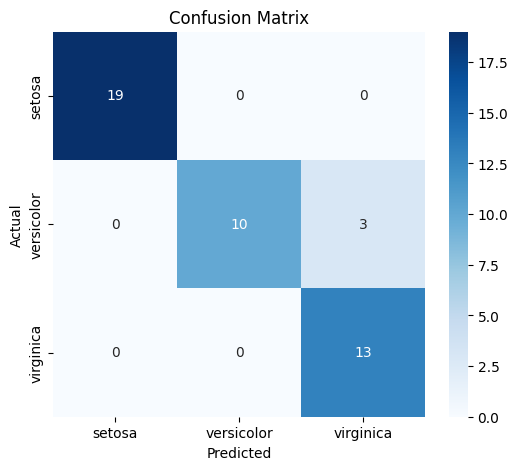

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print("Dataset:\n")
print(df.head())

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# -----------------------------
# Build ANN Model
# -----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(5,),
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Prediction Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Table:\n")
print(result)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Experiment 5: K-Nearest Neighbours (K-NN) in Python

Dataset:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Prediction Table:

    Actual  Predicted
0        1          1
1        0          0
2        2          2
3        1          1
4        1          1
5        0          0
6        1          1
7        2          2
8        1          1
9        1          1
10       2          2
11       0          0
12       0          0
13       0          0
14       0          0
15       1          1
16       2          2
17       1          1

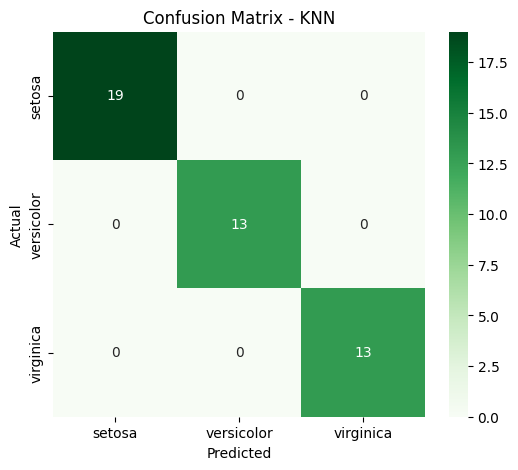

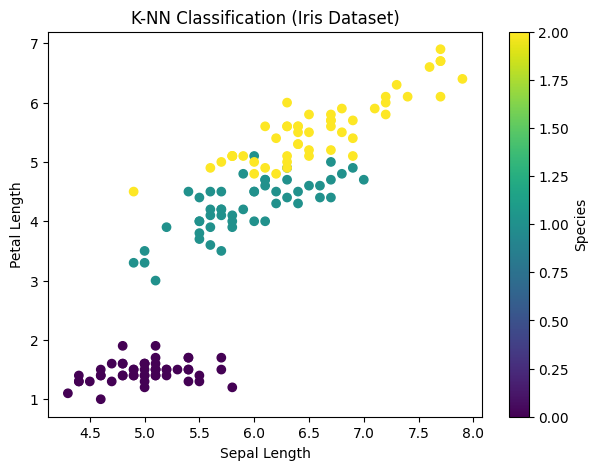

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print("Dataset:\n")
print(df.head())

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# -----------------------------
# Create KNN Model
# -----------------------------
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Prediction Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Table:\n")
print(result)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------
# Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# Scatter Plot Visualization
# -----------------------------
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X[:,0],
    X[:,2],
    c=y,
    cmap="viridis"
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("K-NN Classification (Iris Dataset)")

plt.colorbar(scatter, label="Species")

plt.show()

# Experiment 6: Naïve Bayes Algorithm in Python

Dataset:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Prediction Table:

   Actual  Predicted
0       1          1
1       0          0
2       2          2
3       1          1
4       1          1

Accuracy: 97.78 %

Confusion Matrix:

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


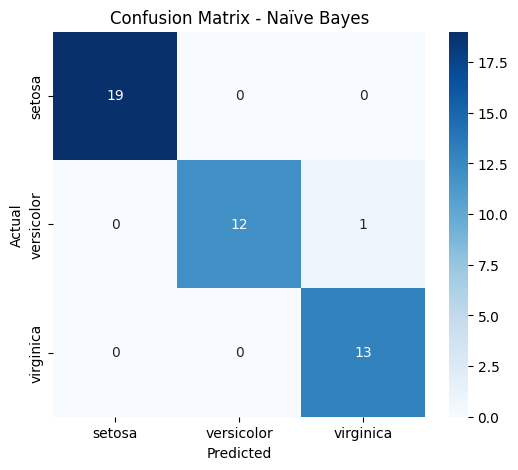

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print("Dataset:\n")
print(df.head())

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# -----------------------------
# Create Naïve Bayes Model
# -----------------------------
model = GaussianNB()

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Prediction Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Table:\n")
print(result.head())

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------
# Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Experiment 7: Logistic Regression (LR) Algorithm in Python

Dataset:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Prediction Table:

   Actual  Predicted
0       1          1
1       0          0
2       2          2
3       1          1
4       1          1

Accuracy: 97.78 %

Confusion Matrix:

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


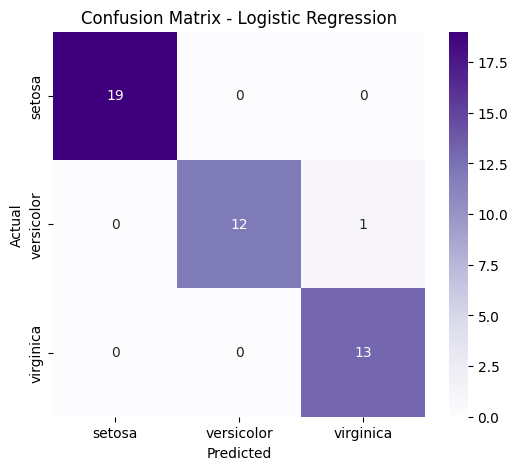

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print("Dataset:\n")
print(df.head())

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# -----------------------------
# Create Logistic Regression Model
# -----------------------------
# Using 'liblinear' solver for multiclass classification as it's good for small datasets
# 'multi_class' is set to 'ovr' (One-vs-Rest) for handling multiple classes
model = LogisticRegression(
    solver='liblinear',
    multi_class='ovr',
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Prediction Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Table:\n")
print(result.head())

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------
# Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Experiment 8: Linear Regression (LR) Algorithm in Python

Dataset (first 5 rows):

    Feature     Target
0  0.931280  62.687202
1  0.087047 -23.763981
2 -1.057711 -25.686766
3  0.314247   7.936457
4 -0.479174 -15.475495

Prediction Table (first 5 rows):

       Actual  Predicted
0  -42.458212 -63.057249
1  116.377367  68.629159
2   54.902670  37.404123
3    4.544398 -19.128091
4   -5.475043 -11.715438

Mean Squared Error (MSE): 413.89
R-squared (R2): 0.81


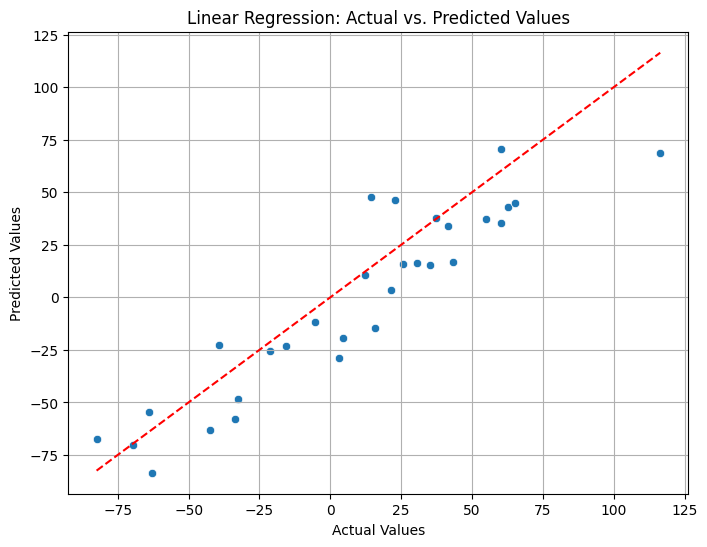

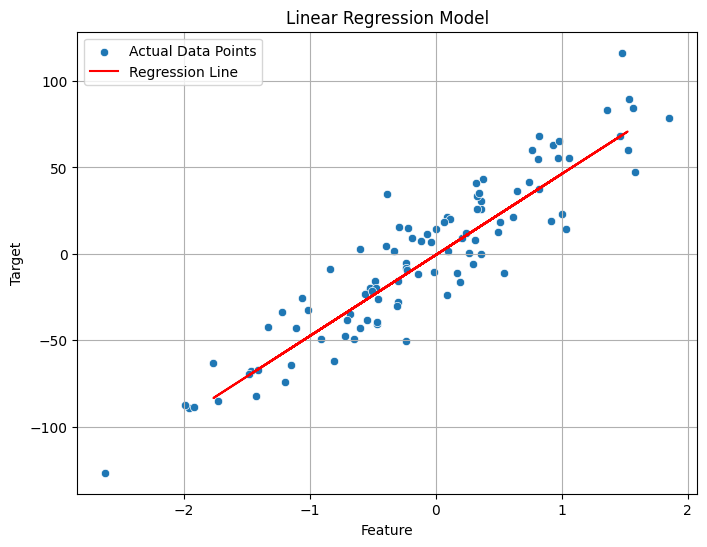

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Generate Synthetic Dataset for Regression
# -----------------------------
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)

# Convert to DataFrame for better viewing
df = pd.DataFrame(X, columns=['Feature'])
df['Target'] = y

print("Dataset (first 5 rows):\n")
print(df.head())

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# -----------------------------
# Create Linear Regression Model
# -----------------------------
model = LinearRegression()

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Prediction Table (for a few samples)
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted": y_pred.flatten()
})

print("\nPrediction Table (first 5 rows):\n")
print(result.head())

# -----------------------------
# Evaluation Metrics
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# -----------------------------
# Visualization: Actual vs. Predicted Values
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

# -----------------------------
# Visualization: Regression Line
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X.flatten(), y=y.flatten(), label='Actual Data Points')
plt.plot(X_test.flatten(), y_pred.flatten(), color='red', label='Regression Line')
plt.title('Linear Regression Model')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

# Experiment 9: Compare Linear and Polynomial Regression using Python

Dataset (first 5 rows):

    Feature     Target
0  0.055221  13.168824
1  0.205845  20.363562
2  0.254191   7.392086
3  0.343885  24.373544
4  0.452273 -17.240748

--- Linear Regression ---
Mean Squared Error (MSE): 729.78
R-squared (R2): 0.72

--- Polynomial Regression (Degree 2) ---
Mean Squared Error (MSE): 225.08
R-squared (R2): 0.91


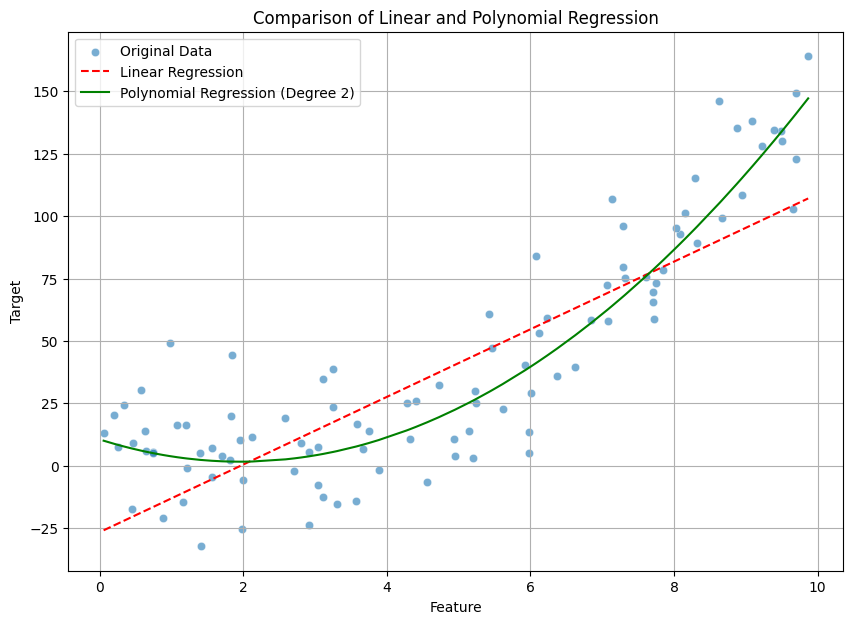


--- Comparison Summary ---
As observed from the metrics and the plot:
- Linear Regression attempts to fit a straight line to the data.
- Polynomial Regression (degree 2) fits a curve, which is more appropriate for the generated non-linear data.
- The R-squared value for Polynomial Regression is significantly higher, and MSE is lower, indicating a much better fit to the non-linear dataset compared to Linear Regression.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Generate Synthetic Non-linear Dataset
# -----------------------------
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Features
y = 2 * X**2 - 5 * X + 3 + np.random.randn(100, 1) * 20 # Non-linear target with noise

# Sort X for better plotting of regression lines
sorted_indices = np.argsort(X.flatten())
X_sorted = X[sorted_indices]
y_sorted = y[sorted_indices]

# Convert to DataFrame for viewing
df = pd.DataFrame(X_sorted, columns=['Feature'])
df['Target'] = y_sorted

print("Dataset (first 5 rows):\n")
print(df.head())

# -----------------------------
# Split Data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 1. Linear Regression
# -----------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"\n--- Linear Regression ---")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

# -----------------------------
# 2. Polynomial Regression (Degree 2)
# -----------------------------
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"\n--- Polynomial Regression (Degree 2) ---")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X.flatten(), y=y.flatten(), label='Original Data', alpha=0.6)

# Plot Linear Regression line
plt.plot(X_sorted.flatten(), linear_model.predict(X_sorted).flatten(), color='red', linestyle='--', label='Linear Regression')

# Plot Polynomial Regression line
X_sorted_poly = poly_features.transform(X_sorted)
plt.plot(X_sorted.flatten(), poly_model.predict(X_sorted_poly).flatten(), color='green', linestyle='-', label='Polynomial Regression (Degree 2)')

plt.title('Comparison of Linear and Polynomial Regression')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Comparison Summary ---")
print("As observed from the metrics and the plot:")
print("- Linear Regression attempts to fit a straight line to the data.")
print("- Polynomial Regression (degree 2) fits a curve, which is more appropriate for the generated non-linear data.")
print("- The R-squared value for Polynomial Regression is significantly higher, and MSE is lower, indicating a much better fit to the non-linear dataset compared to Linear Regression.")

# Experiment 10: Expectation & Maximization Algorithm

Dataset (first 5 rows):

   Feature_1  Feature_2  True_Cluster
0  -7.201180  -7.475001             2
1  -7.481917  -7.149298             2
2  -1.933416   8.159696             0
3   4.487502   2.742313             1
4  -8.306314  -7.585770             2

Predicted Cluster assignments (first 5 samples):

[1 1 0 2 1]

Probabilities of belonging to each cluster (first 5 samples):

[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

Average Log-Likelihood of the samples: -3.16
Adjusted Rand Index (ARI): 1.00


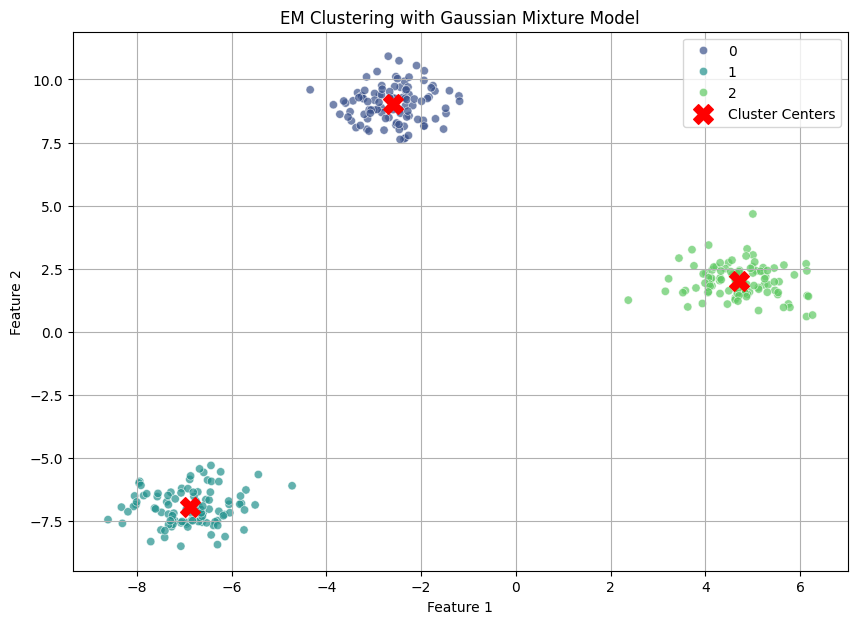


Summary of EM Algorithm Implementation:
The Expectation-Maximization algorithm, as implemented by GaussianMixture, successfully identified the underlying clusters in the synthetic dataset.
Each data point is assigned to a cluster based on its probability of belonging to each Gaussian distribution.
The visualization shows the data points colored by their predicted clusters and the red 'X' marks indicating the centroids (means) of the Gaussian components.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------
n_samples = 300
n_components = 3 # Number of clusters/components

# Create a dataset with distinct blobs (clusters)
X, y_true = make_blobs(
    n_samples=n_samples,
    centers=n_components,
    cluster_std=0.7,
    random_state=42
)

# Convert to DataFrame for better viewing (optional, but good for consistency)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['True_Cluster'] = y_true

print("Dataset (first 5 rows):\n")
print(df.head())

# -----------------------------
# Implement Expectation-Maximization (EM) with Gaussian Mixture Model
# -----------------------------
gmm = GaussianMixture(
    n_components=n_components,
    random_state=42,
    covariance_type='full' # 'full', 'tied', 'diag', 'spherical'
)

gmm.fit(X)

# Predict the clusters for each data point
# y_pred will contain the cluster assignment for each sample
y_pred = gmm.predict(X)

# Get the probabilities of each sample belonging to each cluster
# This is the 'expectation' step output
proba = gmm.predict_proba(X)

print("\nPredicted Cluster assignments (first 5 samples):\n")
print(y_pred[:5])

print("\nProbabilities of belonging to each cluster (first 5 samples):\n")
print(np.round(proba[:5], 2))

# -----------------------------
# Evaluation (Log-likelihood and ARI - adjusted_rand_score if true labels are known)
# -----------------------------
# The score method returns the average log-likelihood of the samples
log_likelihood = gmm.score(X)
print(f"\nAverage Log-Likelihood of the samples: {log_likelihood:.2f}")

# If true labels are available, we can compare clustering quality
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.2f}")


# -----------------------------
# Visualization of Clusters
# -----------------------------
plt.figure(figsize=(10, 7))

# Scatter plot of data points colored by predicted clusters
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y_pred,
    palette=sns.color_palette('viridis', n_components),
    legend='full',
    alpha=0.7
)

# Plot the cluster centers (means of the Gaussians)
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker='X',
    s=200,
    color='red',
    label='Cluster Centers'
)

plt.title('EM Clustering with Gaussian Mixture Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


print("\nSummary of EM Algorithm Implementation:")
print("The Expectation-Maximization algorithm, as implemented by GaussianMixture, successfully identified the underlying clusters in the synthetic dataset.")
print("Each data point is assigned to a cluster based on its probability of belonging to each Gaussian distribution.")
print("The visualization shows the data points colored by their predicted clusters and the red 'X' marks indicating the centroids (means) of the Gaussian components.")

# Experiment 11: Credit Score Classification

Credit Score Dataset (Generated):


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Credit_Mix,Credit_Score
0,56,23343,3680,8,5,32,3,Standard,Poor
1,69,33500,6392,3,3,30,29,Bad,Good
2,46,73222,8543,2,9,12,0,Standard,Poor
3,32,49375,1637,3,1,18,3,Standard,Poor
4,60,29662,7827,5,1,21,17,Standard,Standard



Accuracy Score: 37.0 %

Classification Report:
               precision    recall  f1-score   support

        Good       0.41      0.30      0.35        40
        Poor       0.35      0.45      0.39        33
    Standard       0.36      0.37      0.36        27

    accuracy                           0.37       100
   macro avg       0.37      0.37      0.37       100
weighted avg       0.38      0.37      0.37       100



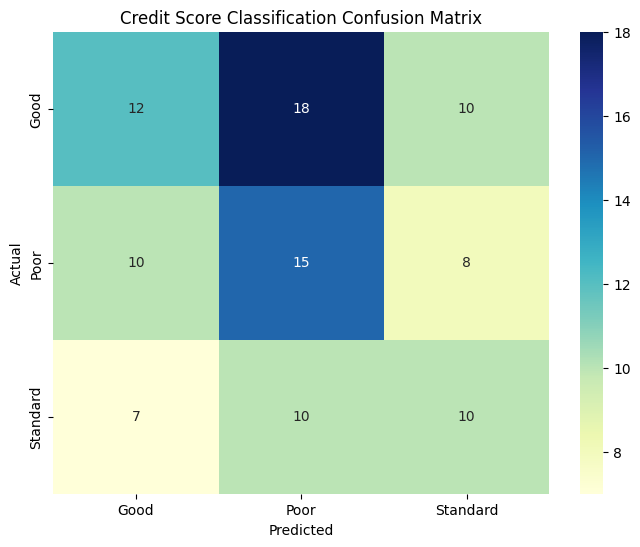

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Create a Synthetic Credit Dataset
np.random.seed(42)
data_size = 500

data = {
    'Age': np.random.randint(18, 70, size=data_size),
    'Annual_Income': np.random.randint(20000, 150000, size=data_size),
    'Monthly_Inhand_Salary': np.random.randint(1500, 10000, size=data_size),
    'Num_Bank_Accounts': np.random.randint(1, 10, size=data_size),
    'Num_Credit_Card': np.random.randint(1, 12, size=data_size),
    'Interest_Rate': np.random.randint(1, 35, size=data_size),
    'Delay_from_due_date': np.random.randint(0, 30, size=data_size),
    'Credit_Mix': np.random.choice(['Bad', 'Standard', 'Good'], size=data_size),
    'Credit_Score': np.random.choice(['Poor', 'Standard', 'Good'], size=data_size)
}

df = pd.DataFrame(data)

# Display first few rows
print("Credit Score Dataset (Generated):")
display(df.head())

# 2. Preprocessing
le = LabelEncoder()
df['Credit_Mix'] = le.fit_transform(df['Credit_Mix'])

# Define Features and Target
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)

print("\nAccuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Credit Score Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Experiment 12: Iris Flower Classification using KNN

This experiment is covered by the comprehensive K-Nearest Neighbours (K-NN) implementation in Experiment 5, which uses the Iris dataset for demonstration.

Iris Dataset Sample:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



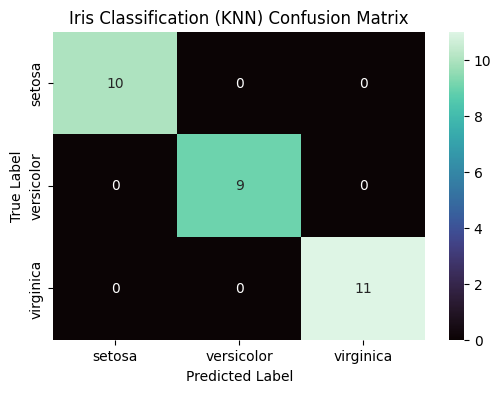

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for visualization
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['species'] = y

print("Iris Dataset Sample:")
display(df_iris.head())

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train KNN Classifier
# We'll use k=3 for this classification task
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 4. Make Predictions
y_pred = knn.predict(X_test)

# 5. Evaluate the Model
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Iris Classification (KNN) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Experiment 13: Car Price Prediction Model using Python

Car Price Dataset Sample:


,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Selling_Price
0,2016,8.382185,8343,CNG,Individual,Manual,3.295876
1,2013,13.959018,18500,Petrol,Individual,Automatic,4.375049
2,2022,24.904413,58222,Diesel,Individual,Automatic,18.628697
3,2020,26.100456,34375,CNG,Dealer,Automatic,19.548503
4,2017,2.194660,14662,CNG,Individual,Automatic,0.500000



R-squared Score: 0.97
Mean Absolute Error: 0.84


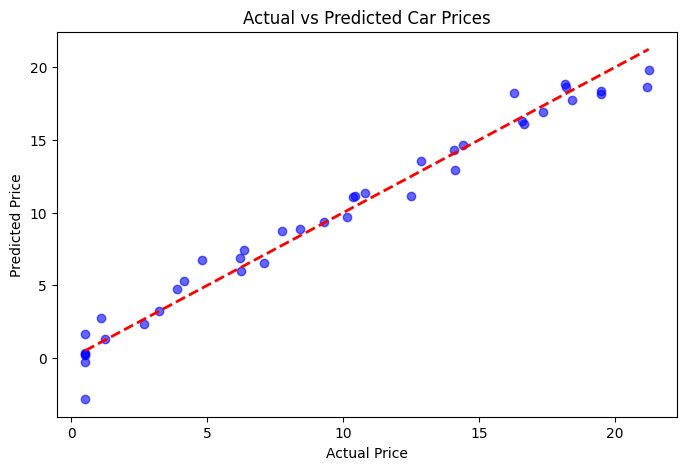

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Create a Synthetic Car Price Dataset
np.random.seed(42)
data_size = 200

data = {
    'Year': np.random.randint(2010, 2023, size=data_size),
    'Present_Price': np.random.uniform(2, 30, size=data_size), # In Lakhs
    'Kms_Driven': np.random.randint(5000, 100000, size=data_size),
    'Fuel_Type': np.random.choice(['Petrol', 'Diesel', 'CNG'], size=data_size),
    'Seller_Type': np.random.choice(['Dealer', 'Individual'], size=data_size),
    'Transmission': np.random.choice(['Manual', 'Automatic'], size=data_size)
}

df_car = pd.DataFrame(data)

# Target variable calculation (Price decreases with age and Kms)
df_car['Selling_Price'] = (df_car['Present_Price'] * 0.8) - (2024 - df_car['Year']) * 0.5 - (df_car['Kms_Driven'] / 50000) + np.random.normal(0, 1, data_size)
df_car['Selling_Price'] = df_car['Selling_Price'].clip(lower=0.5)

print("Car Price Dataset Sample:")
display(df_car.head())

# 2. Preprocessing: Encoding categorical variables
df_car = pd.get_dummies(df_car, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# 3. Split Data
X = df_car.drop('Selling_Price', axis=1)
y = df_car['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Linear Regression Model
car_model = LinearRegression()
car_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = car_model.predict(X_test)

# 6. Evaluation
print(f"\nR-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

# 7. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

# Experiment 14: House Price Prediction using appropriate machine learning algorithm

House Price Dataset Sample:


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Quality,Price
0,1360,4,1,1983,8.356992,274808.962645
1,4272,3,1,1998,4.076356,695387.566174
2,3592,4,2,1999,3.334811,583233.985002
3,966,2,3,2012,4.417232,173592.128584
4,4926,2,1,1999,6.312654,787663.344663



R-squared Score: 0.99
Root Mean Squared Error: $16,741.98


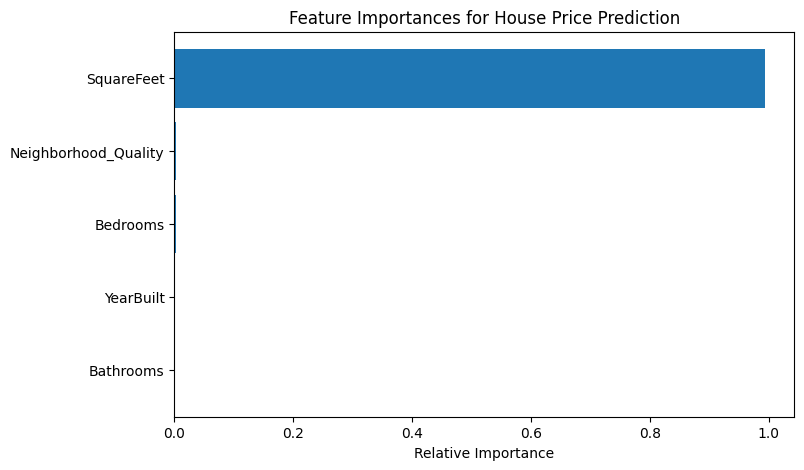

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create a Synthetic House Price Dataset
np.random.seed(42)
data_size = 300

data = {
    'SquareFeet': np.random.randint(500, 5000, size=data_size),
    'Bedrooms': np.random.randint(1, 6, size=data_size),
    'Bathrooms': np.random.randint(1, 4, size=data_size),
    'YearBuilt': np.random.randint(1980, 2024, size=data_size),
    'Neighborhood_Quality': np.random.uniform(1, 10, size=data_size)
}

df_house = pd.DataFrame(data)

# Target: Price depends on features + noise
df_house['Price'] = (df_house['SquareFeet'] * 150) + (df_house['Bedrooms'] * 10000) + \
                    (df_house['Neighborhood_Quality'] * 5000) - ((2024 - df_house['YearBuilt']) * 200) + \
                    np.random.normal(0, 5000, data_size)

print("House Price Dataset Sample:")
display(df_house.head())

# 2. Split Data
X = df_house.drop('Price', axis=1)
y = df_house['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest Regressor
house_model = RandomForestRegressor(n_estimators=100, random_state=42)
house_model.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = house_model.predict(X_test)

print(f"\nR-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

# 5. Feature Importance Visualization
importances = house_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importances for House Price Prediction')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Experiment 15: Iris Flower Classification using Naive Bayes classifier

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the Naive Bayes Classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# 4. Make Predictions
y_pred = nb_classifier.predict(X_test)

# 5. Evaluate the Model
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Iris Classification (Naive Bayes) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Experiment 16: Comparison of Classification Algorithms

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale features (important for some models like KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train various classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB()
}

accuracies = {}
classification_reports = {}
confusion_matrices = {}

print("Training and Evaluating Models...")
for name, model in models.items():
    print(f"\n--- {name} ---")
    # Use scaled data for models sensitive to feature scaling
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    report = classification_report(y_test, y_pred, target_names=iris.target_names)
    classification_reports[name] = report

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm

    print(f"Accuracy: {acc * 100:.2f}%")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)

Training and Evaluating Models...

--- Logistic Regression ---
Accuracy: 91.11%
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.69      0.82        13
   virginica       0.76      1.00      0.87        13

    accuracy                           0.91        45
   macro avg       0.92      0.90      0.89        45
weighted avg       0.93      0.91      0.91        45

Confusion Matrix:
 [[19  0  0]
 [ 0  9  4]
 [ 0  0 13]]

--- Decision Tree ---
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Mat

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

--- K-Nearest Neighbors ---
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

--- Naive Ba

### Comparison Summary


--- Model Performance Comparison ---


,Model,Accuracy
1,Decision Tree,1.000000
3,K-Nearest Neighbors,1.000000
2,Random Forest,1.000000
4,Naive Bayes,0.977778
0,Logistic Regression,0.911111


/tmp/ipykernel_2973/1647254343.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=performance_df, palette='viridis')


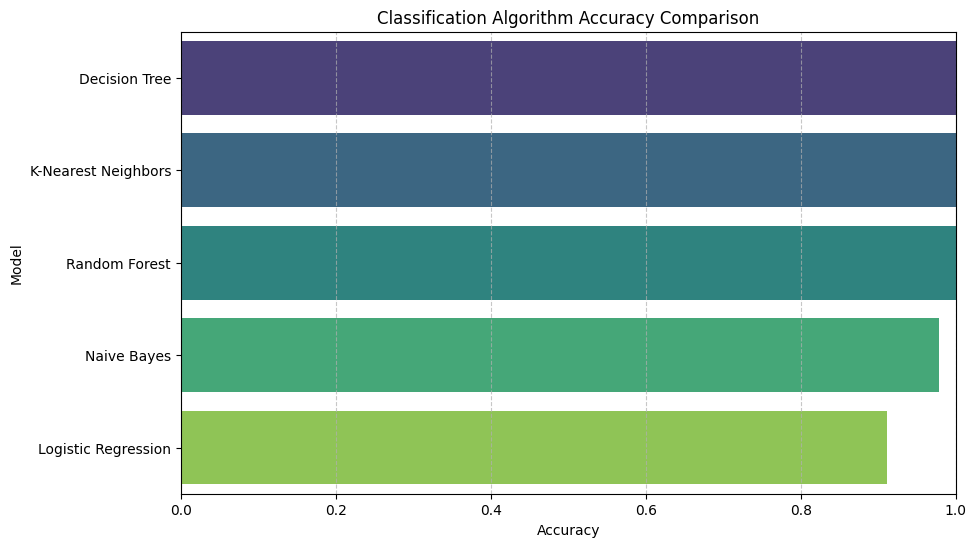


--- Detailed Reports ---

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.69      0.82        13
   virginica       0.76      1.00      0.87        13

    accuracy                           0.91        45
   macro avg       0.92      0.90      0.89        45
weighted avg       0.93      0.91      0.91        45



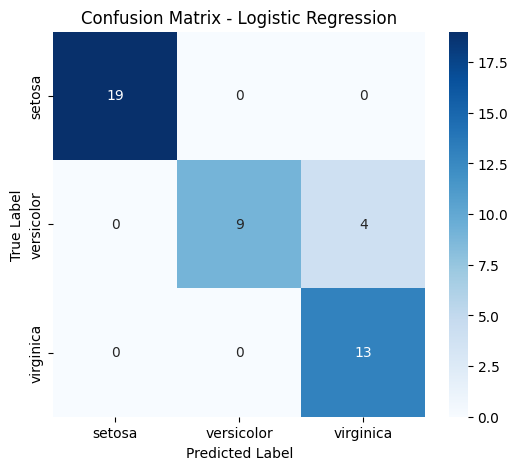


Classification Report for Decision Tree:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



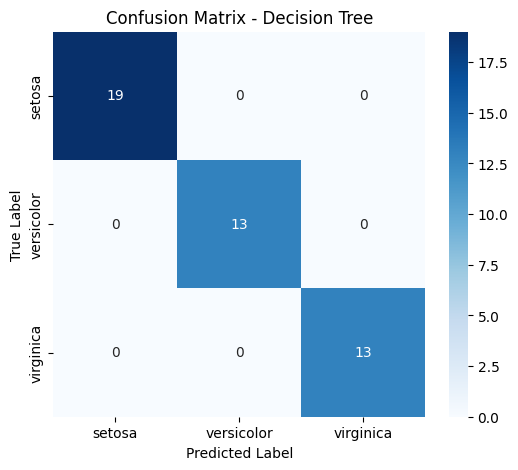


Classification Report for Random Forest:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



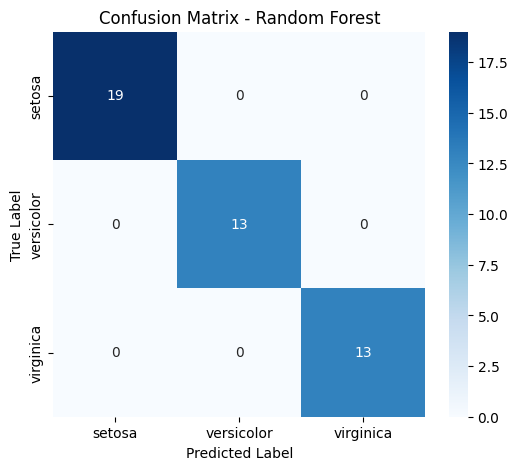


Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



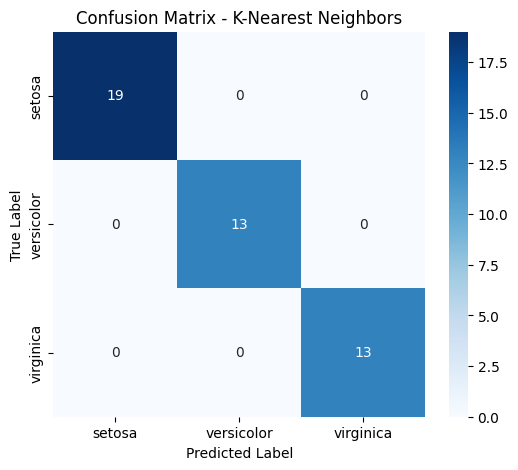


Classification Report for Naive Bayes:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



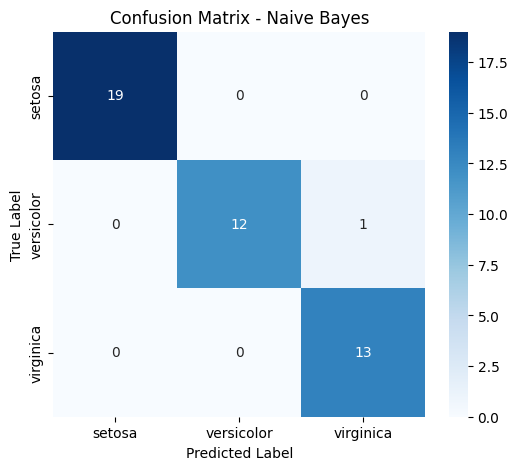

In [3]:
# 5. Visualize and Compare Accuracies
performance_df = pd.DataFrame({
    'Model': list(accuracies.keys()),
    'Accuracy': list(accuracies.values())
})

performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

print("\n--- Model Performance Comparison ---")
display(performance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=performance_df, palette='viridis')
plt.title('Classification Algorithm Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Detailed Reports ---")
for name, report in classification_reports.items():
    print(f"\nClassification Report for {name}:\n{report}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        confusion_matrices[name],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## Experiment 17: Mobile Price Prediction using Random Forest Regressor

Synthetic Mobile Price Dataset Sample:


,RAM_GB,Storage_GB,Screen_Size_Inches,Camera_MP,Battery_mAh,Brand,Processor_Speed_GHz,Price_USD
0,10,128,6.0,73,5558,Xiaomi,3.1,1447.07
1,7,128,6.3,88,4316,Google,3.0,1500.00
2,14,128,6.1,36,4043,OnePlus,2.9,1500.00
3,11,512,6.3,82,3281,Google,2.5,1500.00
4,8,64,6.1,63,5844,Apple,3.3,1500.00



Shape of X_train: (400, 10)
Shape of X_test: (100, 10)

--- Model Evaluation (RandomForestRegressor) ---
Mean Squared Error (MSE): 2404.29
Root Mean Squared Error (RMSE): 49.03
Mean Absolute Error (MAE): 21.79
R-squared (R2) Score: 0.72


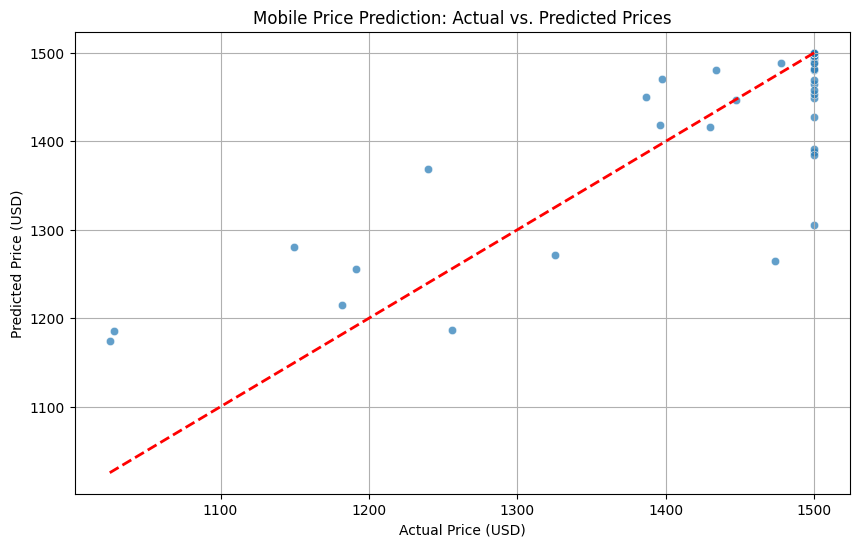

/tmp/ipykernel_2973/2043775560.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


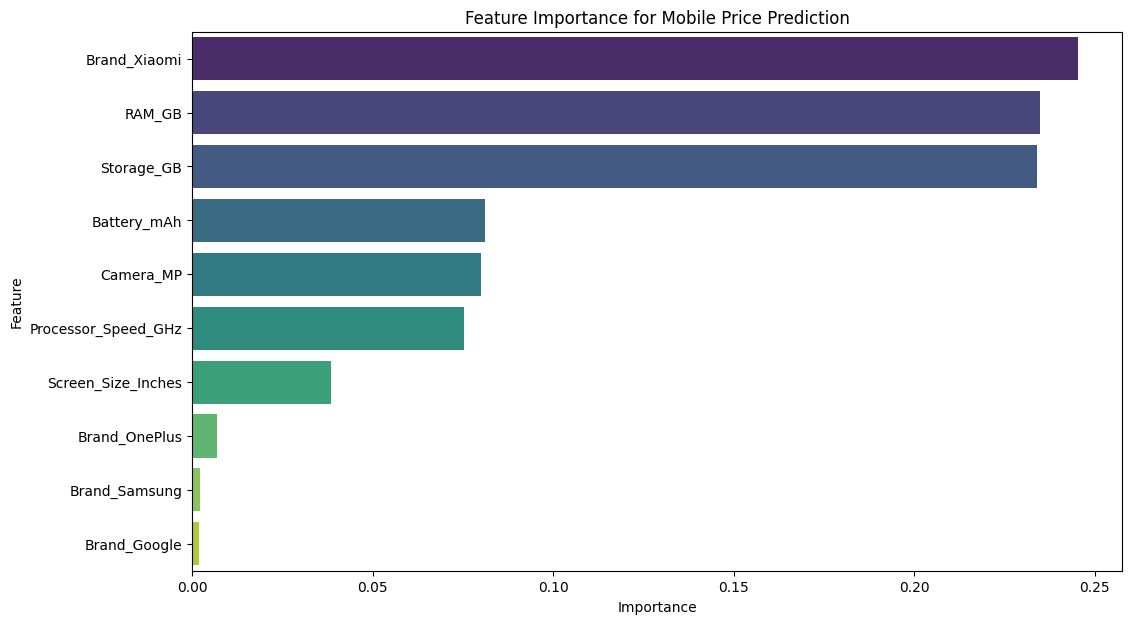

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1. Create a Synthetic Mobile Phone Dataset
np.random.seed(42)
data_size = 500

data = {
    'RAM_GB': np.random.randint(4, 16, size=data_size),
    'Storage_GB': np.random.choice([64, 128, 256, 512], size=data_size),
    'Screen_Size_Inches': np.random.uniform(5.5, 6.9, size=data_size).round(1),
    'Camera_MP': np.random.randint(12, 108, size=data_size),
    'Battery_mAh': np.random.randint(3000, 6000, size=data_size),
    'Brand': np.random.choice(['Samsung', 'Apple', 'Xiaomi', 'OnePlus', 'Google'], size=data_size),
    'Processor_Speed_GHz': np.random.uniform(2.0, 3.5, size=data_size).round(1)
}

df_mobile = pd.DataFrame(data)

# Generate 'Price_USD' based on features with some noise
df_mobile['Price_USD'] = (
    (df_mobile['RAM_GB'] * 50) +
    (df_mobile['Storage_GB'] * 1.5) +
    (df_mobile['Screen_Size_Inches'] * 70) +
    (df_mobile['Camera_MP'] * 2) +
    (df_mobile['Battery_mAh'] * 0.05) +
    (df_mobile['Processor_Speed_GHz'] * 100) +
    np.random.normal(0, 100, data_size) # Add some random noise
)

# Adjust price for brands (e.g., Apple and Samsung might be pricier)
df_mobile.loc[df_mobile['Brand'] == 'Apple', 'Price_USD'] *= 1.3
df_mobile.loc[df_mobile['Brand'] == 'Samsung', 'Price_USD'] *= 1.1
df_mobile.loc[df_mobile['Brand'] == 'Xiaomi', 'Price_USD'] *= 0.8

df_mobile['Price_USD'] = df_mobile['Price_USD'].round(2).clip(lower=300, upper=1500) # Ensure realistic price range

print("Synthetic Mobile Price Dataset Sample:")
display(df_mobile.head())

# 2. Preprocessing: Encoding categorical variables and scaling numerical features
df_processed = pd.get_dummies(df_mobile, columns=['Brand'], drop_first=True)

# Define features (X) and target (y)
X = df_processed.drop('Price_USD', axis=1)
y = df_processed['Price_USD']

# Scale numerical features
# Identify numerical columns for scaling (excluding dummy variables)
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# 4. Train the Machine Learning Model (RandomForestRegressor)
mobile_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
mobile_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = mobile_model.predict(X_test)

# 6. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation (RandomForestRegressor) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# 7. Visualization: Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # Diagonal line
plt.title('Mobile Price Prediction: Actual vs. Predicted Prices')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True)
plt.show()

# 8. Feature Importance
feature_importances = pd.Series(mobile_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance for Mobile Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Experiment 18: Perceptron based IRIS Classification

Iris Dataset Sample:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Accuracy: 88.89%

Classification Report:
               precision    recall  f1-score   support

      setosa       0.95      1.00      0.97        19
  versicolor       1.00      0.62      0.76        13
   virginica       0.76      1.00      0.87        13

    accuracy                           0.89        45
   macro avg       0.90      0.87      0.87        45
weighted avg       0.91      0.89      0.88        45



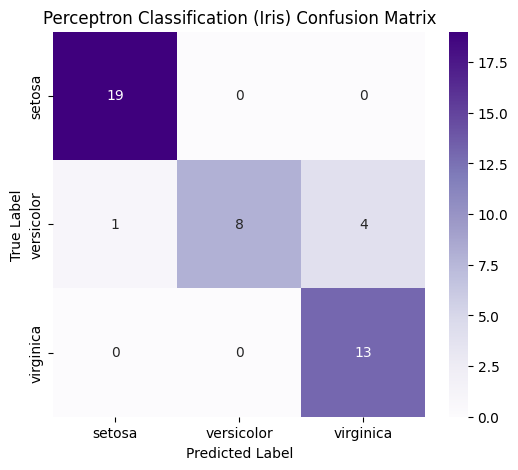

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['species'] = y

print("Iris Dataset Sample:")
display(df_iris.head())

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale features (important for Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the Perceptron model
# random_state for reproducibility, eta0 is the learning rate
perceptron_model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron_model.fit(X_train_scaled, y_train)

# 5. Make Predictions
y_pred = perceptron_model.predict(X_test_scaled)

# 6. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# 7. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title('Perceptron Classification (Iris) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Experiment 19: Naive Bayes Classification for Bank Loan Prediction

Synthetic Bank Loan Dataset Sample:


,Loan_Amount,Credit_Score,Income,Loan_Term,Employment_Years,Has_Property,Loan_Status
0,20795,464,115155,12,9,0,Rejected
1,5860,304,60461,12,14,1,Rejected
2,43158,678,93800,60,18,0,Approved
3,49732,377,98222,12,15,0,Rejected
4,16284,709,44226,12,3,0,Approved



Shape of X_train: (700, 6)
Shape of X_test: (300, 6)

--- Model Evaluation (Gaussian Naive Bayes) ---
Accuracy: 78.00%

Classification Report:
               precision    recall  f1-score   support

    Approved       0.70      0.81      0.75       122
    Rejected       0.85      0.76      0.80       178

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.79      0.78      0.78       300



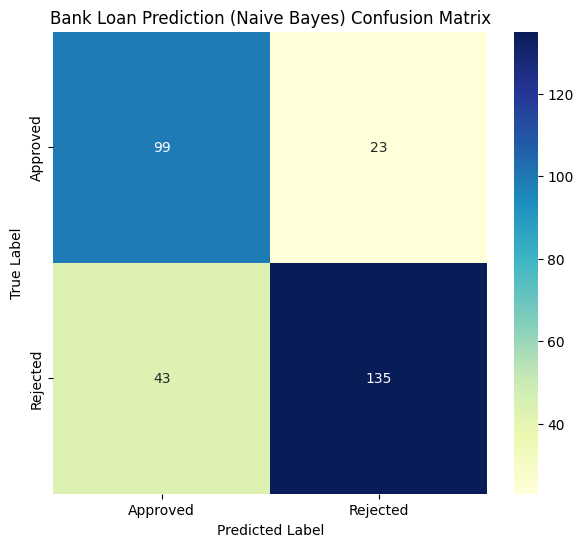

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Create a Synthetic Bank Loan Dataset
np.random.seed(42)
data_size = 1000

data = {
    'Loan_Amount': np.random.randint(5000, 50000, size=data_size),
    'Credit_Score': np.random.randint(300, 850, size=data_size),
    'Income': np.random.randint(20000, 120000, size=data_size),
    'Loan_Term': np.random.choice([12, 24, 36, 48, 60], size=data_size),
    'Employment_Years': np.random.randint(0, 20, size=data_size),
    'Has_Property': np.random.choice([0, 1], size=data_size), # 0 for No, 1 for Yes
    'Loan_Status': np.random.choice(['Approved', 'Rejected'], size=data_size, p=[0.7, 0.3])
}

df_loan = pd.DataFrame(data)

# Introduce some correlation for 'Loan_Status'
# Higher credit score, income, and employment years should lean towards 'Approved'
df_loan.loc[(df_loan['Credit_Score'] > 700) & (df_loan['Income'] > 60000) & (df_loan['Employment_Years'] > 5), 'Loan_Status'] = 'Approved'
df_loan.loc[(df_loan['Credit_Score'] < 500) | (df_loan['Income'] < 30000), 'Loan_Status'] = 'Rejected'

print("Synthetic Bank Loan Dataset Sample:")
display(df_loan.head())

# 2. Preprocessing
# Encode target variable
le = LabelEncoder()
df_loan['Loan_Status_Encoded'] = le.fit_transform(df_loan['Loan_Status'])

# Define features (X) and target (y)
X = df_loan.drop(['Loan_Status', 'Loan_Status_Encoded'], axis=1)
y = df_loan['Loan_Status_Encoded']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for scaled features (optional, but good for inspection)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# 4. Train the Gaussian Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = nb_model.predict(X_test)

# 6. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Evaluation (Gaussian Naive Bayes) ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# 7. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Bank Loan Prediction (Naive Bayes) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Experiment 20: Future Sales Prediction using Random Forest Regressor

Synthetic Future Sales Dataset Sample:


,Month,Advertising_Spend_USD,Marketing_Campaigns,Competitor_Activity,Economic_Index,Previous_Month_Sales_USD,Future_Sales_USD
0,2018-01-01,8270,0,1.2,98.7,96857,216880.148153
1,2018-02-01,1860,1,1.9,90.9,84964,115159.085199
2,2018-03-01,6390,1,1.4,93.2,187050,244348.802689
3,2018-04-01,6191,3,0.5,90.4,67153,221523.918495
4,2018-05-01,6734,0,1.9,103.1,109765,189516.160101



Shape of X_train: (400, 7)
Shape of X_test: (100, 7)

--- Model Evaluation (RandomForestRegressor) ---
Mean Squared Error (MSE): 271010096.73
Root Mean Squared Error (RMSE): 16462.38
Mean Absolute Error (MAE): 13305.69
R-squared (R2) Score: 0.84


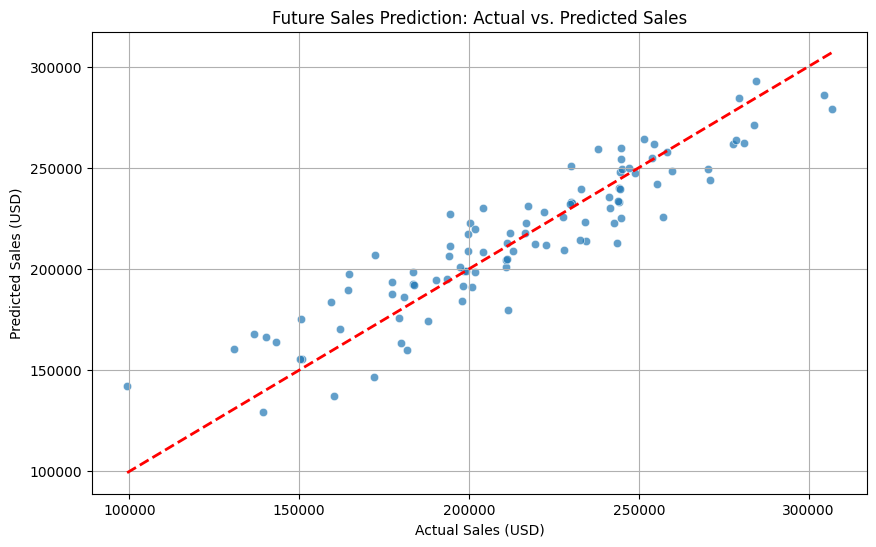

/tmp/ipykernel_2973/2210847467.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')


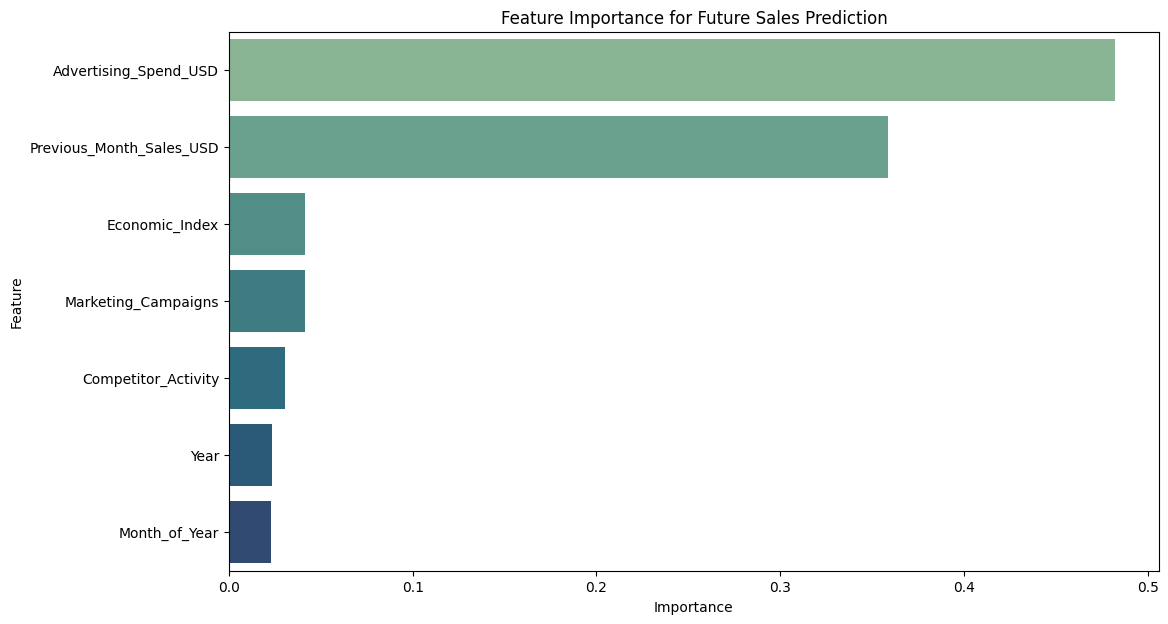

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1. Create a Synthetic Future Sales Dataset
np.random.seed(42)
data_size = 500 # Number of months/periods

# Simulate monthly data
months = pd.date_range(start='2018-01-01', periods=data_size, freq='MS')

data = {
    'Month': months,
    'Advertising_Spend_USD': np.random.randint(1000, 10000, size=data_size),
    'Marketing_Campaigns': np.random.randint(0, 5, size=data_size), # Number of campaigns
    'Competitor_Activity': np.random.uniform(0.5, 2.0, size=data_size).round(1), # Index of competitor activity
    'Economic_Index': np.random.uniform(90.0, 110.0, size=data_size).round(1),
    'Previous_Month_Sales_USD': np.random.randint(50000, 200000, size=data_size)
}

df_sales = pd.DataFrame(data)

# Generate 'Future_Sales_USD' based on features with some noise and trends
# Sales generally increase with advertising, campaigns, economic index, and previous sales
# Sales generally decrease with competitor activity
df_sales['Future_Sales_USD'] = (
    (df_sales['Advertising_Spend_USD'] * 10) +
    (df_sales['Marketing_Campaigns'] * 5000) +
    (df_sales['Economic_Index'] * 1000) -
    (df_sales['Competitor_Activity'] * 10000) +
    (df_sales['Previous_Month_Sales_USD'] * 0.5) +
    np.random.normal(0, 15000, data_size) # Add some random noise
)

# Ensure sales are realistic (e.g., positive and within a reasonable range)
df_sales['Future_Sales_USD'] = df_sales['Future_Sales_USD'].clip(lower=20000, upper=500000)

print("Synthetic Future Sales Dataset Sample:")
display(df_sales.head())

# 2. Preprocessing
# Convert 'Month' to numerical feature (e.g., month of year, year, or simply drop for now)
df_sales['Year'] = df_sales['Month'].dt.year
df_sales['Month_of_Year'] = df_sales['Month'].dt.month

X = df_sales.drop(['Month', 'Future_Sales_USD'], axis=1)
y = df_sales['Future_Sales_USD']

# Scale numerical features (Random Forest is less sensitive but good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame for consistency with column names
X_processed = pd.DataFrame(X_scaled, columns=X.columns)

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# 4. Train the Machine Learning Model (RandomForestRegressor)
sales_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
sales_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = sales_model.predict(X_test)

# 6. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation (RandomForestRegressor) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# 7. Visualization: Actual vs. Predicted Future Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # Diagonal line
plt.title('Future Sales Prediction: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales (USD)')
plt.ylabel('Predicted Sales (USD)')
plt.grid(True)
plt.show()

# 8. Feature Importance
feature_importances = pd.Series(sales_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')
plt.title('Feature Importance for Future Sales Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()